# Metrics Evaluation

This notebook computes quantitative evaluation metrics for all experiments:

- SSIM
- LPIPS
- CLIP Score
- Runtime

In [2]:
!pip -q install scikit-image lpips transformers pillow pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.2 MB/s eta 0:00:00


In [3]:
import os
import re
import torch
import lpips
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

from PIL import Image
from IPython.display import display
from skimage.metrics import structural_similarity as ssim
from transformers import CLIPProcessor, CLIPModel

In [4]:
repo_dir = "/content/image-data-generation"

experiments = {
    "baseline_vs_controlnet": f"{repo_dir}/results/baseline_vs_controlnet",
    "controlnet_vs_ipadapter": f"{repo_dir}/results/controlnet_vs_ipadapter",
    "full_pipeline_ablation": f"{repo_dir}/results/full_pipeline_ablation",
    "multi_weather_evaluation": f"{repo_dir}/results/multi_weather_evaluation",
}

metrics_dir = f"{repo_dir}/results/metrics"
os.makedirs(metrics_dir, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [5]:
def load_image(path, size=(512, 512)):
    return Image.open(path).convert("RGB").resize(size)

def image_to_numpy(img):
    return np.array(img)

def calculate_ssim(original, generated):
    original_np = image_to_numpy(original)
    generated_np = image_to_numpy(generated)

    return ssim(original_np,generated_np,channel_axis=2,data_range=255)

def read_runtime(metadata_path, label):
    if not os.path.exists(metadata_path):
        return None

    with open(metadata_path, "r") as f:
        text = f.read()

    patterns = {
        "baseline_sd": r"Baseline runtime: ([0-9.]+)",
        "controlnet_depth": r"ControlNet runtime: ([0-9.]+)",
        "controlnet_only": r"ControlNet runtime: ([0-9.]+)",
        "controlnet_ipadapter": r"ControlNet \+ IP-Adapter runtime: ([0-9.]+)",
        "full_pipeline": r"Full pipeline runtime: ([0-9.]+)",
        "without_ipadapter": r"Without IP-Adapter runtime: ([0-9.]+)",
        "without_blip2": r"Without BLIP-2 runtime: ([0-9.]+)",
        "without_controlnet": r"Without ControlNet runtime: ([0-9.]+)",
        "generated_output": r"Runtime: ([0-9.]+)",
    }

    pattern = patterns.get(label)

    if pattern is None:
        return None

    match = re.search(pattern, text)

    if match:
        return float(match.group(1))

    return None

In [6]:
# lpips
lpips_model = lpips.LPIPS(net="alex").to(device)
lpips_model.eval()


def calculate_lpips(original, generated):
    original_tensor = torch.tensor(np.array(original)).permute(2, 0, 1).unsqueeze(0).float()
    generated_tensor = torch.tensor(np.array(generated)).permute(2, 0, 1).unsqueeze(0).float()

    original_tensor = (original_tensor / 127.5 - 1.0).to(device)
    generated_tensor = (generated_tensor / 127.5 - 1.0).to(device)

    with torch.no_grad():
        score = lpips_model(original_tensor, generated_tensor)

    return float(score.item())

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 102MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [7]:
# clip
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()


def calculate_clip_score(image, prompt):
    inputs = clip_processor(
        text=[prompt],
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds

        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

        score = (image_embeds @ text_embeds.T).item()

    return score

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [8]:
weather_clip_prompts = {
    "snow": "snowy winter road scene with heavy snowfall",
    "rain": "rainy road scene with wet roads and rainfall",
    "fog": "foggy road scene with reduced visibility",
}

def read_metadata_field(metadata_path, field_name):
    if not os.path.exists(metadata_path):
        return None

    with open(metadata_path, "r") as f:
        for line in f:
            if line.startswith(f"{field_name}:"):
                return line.split(":", 1)[1].strip()
    return None

def get_clip_prompt(metadata_path, experiment_name):
    weather_condition = read_metadata_field(metadata_path, "Weather condition")

    if weather_condition in weather_clip_prompts:
        return weather_clip_prompts[weather_condition]

    # All experiments apart from multi weather use the controlled snow condition.
    return weather_clip_prompts["snow"]

In [9]:
output_files = [
    "baseline_sd.png",
    "controlnet_depth.png",
    "controlnet_only.png",
    "controlnet_ipadapter.png",
    "full_pipeline.png",
    "without_ipadapter.png",
    "without_controlnet.png",
    "without_blip2.png",
]

rows = []

for experiment_name, experiment_dir in experiments.items():
    if not os.path.exists(experiment_dir):
        print("Skipping missing experiment:", experiment_name)
        continue

    # Multi-weather outputs are stored as:
    # results/multi_weather_evaluation/road_01/snow_ref1/generated_output.png
    if experiment_name == "multi_weather_evaluation":
        road_folders = sorted([
            f for f in os.listdir(experiment_dir)
            if os.path.isdir(os.path.join(experiment_dir, f))
        ])

        for road_id in road_folders:
            road_dir = os.path.join(experiment_dir, road_id)

            run_folders = sorted([
                f for f in os.listdir(road_dir)
                if os.path.isdir(os.path.join(road_dir, f))
            ])

            for run_id in run_folders:
                run_dir = os.path.join(road_dir, run_id)

                original_path = os.path.join(run_dir, "original.png")
                output_path = os.path.join(run_dir, "generated_output.png")
                metadata_path = os.path.join(run_dir, "metadata.txt")

                if not os.path.exists(original_path) or not os.path.exists(output_path):
                    continue

                original = load_image(original_path)
                generated = load_image(output_path)

                model_name = "generated_output"
                clip_prompt = get_clip_prompt(metadata_path, experiment_name)

                weather_condition = read_metadata_field(metadata_path, "Weather condition")
                reference_index = read_metadata_field(metadata_path, "Reference index")

                ssim_score = calculate_ssim(original, generated)
                lpips_score = calculate_lpips(original, generated)
                clip_score = calculate_clip_score(generated, clip_prompt)
                runtime = read_runtime(metadata_path, model_name)

                rows.append({
                    "experiment": experiment_name,
                    "image_id": road_id,
                    "model": model_name,
                    "weather_condition": weather_condition,
                    "reference_index": reference_index,
                    "clip_prompt": clip_prompt,
                    "ssim": ssim_score,
                    "lpips": lpips_score,
                    "clip_score": clip_score,
                    "runtime_seconds": runtime,
                    "output_path": output_path
                })

                print(experiment_name, road_id, run_id, "done")

    else:
        road_folders = sorted([
            f for f in os.listdir(experiment_dir)
            if os.path.isdir(os.path.join(experiment_dir, f))
        ])

        for road_id in road_folders:
            road_dir = os.path.join(experiment_dir, road_id)
            original_path = os.path.join(road_dir, "original.png")
            metadata_path = os.path.join(road_dir, "metadata.txt")

            if not os.path.exists(original_path):
                continue

            original = load_image(original_path)

            for output_file in output_files:
                output_path = os.path.join(road_dir, output_file)

                if not os.path.exists(output_path):
                    continue

                model_name = output_file.replace(".png", "")
                generated = load_image(output_path)

                clip_prompt = get_clip_prompt(metadata_path, experiment_name)

                ssim_score = calculate_ssim(original, generated)
                lpips_score = calculate_lpips(original, generated)
                clip_score = calculate_clip_score(generated, clip_prompt)
                runtime = read_runtime(metadata_path, model_name)

                rows.append({
                    "experiment": experiment_name,
                    "image_id": road_id,
                    "model": model_name,
                    "weather_condition": "snow",
                    "reference_index": None,
                    "clip_prompt": clip_prompt,
                    "ssim": ssim_score,
                    "lpips": lpips_score,
                    "clip_score": clip_score,
                    "runtime_seconds": runtime,
                    "output_path": output_path
                })

                print(experiment_name, road_id, model_name, "done")

baseline_vs_controlnet road_01 baseline_sd done
baseline_vs_controlnet road_01 controlnet_depth done
baseline_vs_controlnet road_02 baseline_sd done
baseline_vs_controlnet road_02 controlnet_depth done
baseline_vs_controlnet road_03 baseline_sd done
baseline_vs_controlnet road_03 controlnet_depth done
baseline_vs_controlnet road_04 baseline_sd done
baseline_vs_controlnet road_04 controlnet_depth done
baseline_vs_controlnet road_05 baseline_sd done
baseline_vs_controlnet road_05 controlnet_depth done
baseline_vs_controlnet road_06 baseline_sd done
baseline_vs_controlnet road_06 controlnet_depth done
baseline_vs_controlnet road_07 baseline_sd done
baseline_vs_controlnet road_07 controlnet_depth done
baseline_vs_controlnet road_08 baseline_sd done
baseline_vs_controlnet road_08 controlnet_depth done
baseline_vs_controlnet road_09 baseline_sd done
baseline_vs_controlnet road_09 controlnet_depth done
baseline_vs_controlnet road_10 baseline_sd done
baseline_vs_controlnet road_10 controlnet_d

In [10]:
df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No metric rows were generated. Check that result folders and output files exist.")

print("Total metric rows:", len(df))
print(df["experiment"].value_counts())

csv_path = os.path.join(metrics_dir, "metrics_summary.csv")
df.to_csv(csv_path, index=False)

df.head()

missing_runtime = df[df["runtime_seconds"].isna()]

print("Rows with missing runtime:", len(missing_runtime))

if len(missing_runtime) > 0:
    display(missing_runtime[["experiment", "image_id", "model", "output_path"]].head(20))


,experiment,image_id,model,weather_condition,reference_index,clip_prompt,ssim,lpips,clip_score,runtime_seconds,output_path
0,baseline_vs_controlnet,road_01,baseline_sd,snow,None,snowy winter road scene with heavy snowfall,0.344892,0.559540,0.336533,6.64,/content/image-data-generation/results/baselin...
1,baseline_vs_controlnet,road_01,controlnet_depth,snow,None,snowy winter road scene with heavy snowfall,0.375324,0.504012,0.307560,6.86,/content/image-data-generation/results/baselin...
2,baseline_vs_controlnet,road_02,baseline_sd,snow,None,snowy winter road scene with heavy snowfall,0.133756,0.683459,0.293576,5.07,/content/image-data-generation/results/baselin...
3,baseline_vs_controlnet,road_02,controlnet_depth,snow,None,snowy winter road scene with heavy snowfall,0.194684,0.561368,0.270163,6.92,/content/image-data-generation/results/baselin...
4,baseline_vs_controlnet,road_03,baseline_sd,snow,None,snowy winter road scene with heavy snowfall,0.160607,0.687889,0.282928,5.12,/content/image-data-generation/results/baselin...


In [11]:
summary = df.groupby(["experiment", "model","weather_condition","reference_index"], dropna=False).agg({
    "ssim": "mean",
    "lpips": "mean",
    "clip_score": "mean",
    "runtime_seconds": "mean"
}).reset_index()

def make_label(row):
    experiment = row["experiment"]
    model = row["model"]
    weather = row["weather_condition"]
    ref = row["reference_index"]

    label_map = {
        ("baseline_vs_controlnet", "baseline_sd"): "SD vs ControlNet: SD Only",
        ("baseline_vs_controlnet", "controlnet_depth"): "SD vs ControlNet: SD + ControlNet",

        ("controlnet_vs_ipadapter", "controlnet_only"): "ControlNet vs IP-Adapter: ControlNet Only",
        ("controlnet_vs_ipadapter", "controlnet_ipadapter"): "ControlNet vs IP-Adapter: ControlNet + IP-Adapter",

        ("full_pipeline_ablation", "baseline_sd"): "Ablation: SD Only",
        ("full_pipeline_ablation", "without_controlnet"): "Ablation: Without ControlNet",
        ("full_pipeline_ablation", "without_ipadapter"): "Ablation: Without IP-Adapter",
        ("full_pipeline_ablation", "without_blip2"): "Ablation: Without BLIP-2",
        ("full_pipeline_ablation", "full_pipeline"): "Ablation: Full Pipeline",
    }

    if experiment == "multi_weather_evaluation":
        return f"Multi-weather: {str(weather).capitalize()} Ref {ref}"

    return label_map.get((experiment, model), model)


summary["label"] = summary.apply(make_label, axis=1)

In [12]:
# Ordering
experiment_order = {
    "baseline_vs_controlnet": 1,
    "controlnet_vs_ipadapter": 2,
    "full_pipeline_ablation": 3,
    "multi_weather_evaluation": 4,
}

model_order = {
    "baseline_sd": 1,
    "controlnet_depth": 2,
    "controlnet_only": 1,
    "controlnet_ipadapter": 2,
    "without_controlnet": 2,
    "without_ipadapter": 3,
    "without_blip2": 4,
    "full_pipeline": 5,
    "generated_output": 1,
}

weather_order = {
    "snow": 1,
    "rain": 2,
    "fog": 3,
}

summary["experiment_order"] = summary["experiment"].map(experiment_order)
summary["model_order"] = summary["model"].map(model_order)
summary["weather_order"] = summary["weather_condition"].map(weather_order).fillna(0)
summary["reference_order"] = pd.to_numeric(summary["reference_index"], errors="coerce").fillna(0)

summary = summary.sort_values([
    "experiment_order",
    "model_order",
    "weather_order",
    "reference_order"
])

summary_rounded = summary.copy()

round_cols = ["ssim", "lpips", "clip_score", "runtime_seconds"]
summary_rounded[round_cols] = summary_rounded[round_cols].round(3)

summary_path = os.path.join(metrics_dir, "metrics_average_summary.csv")
summary_rounded.to_csv(summary_path, index=False)

summary_rounded

Rows with missing runtime: 0


,experiment,model,weather_condition,reference_index,ssim,lpips,clip_score,runtime_seconds,label,experiment_order,model_order,weather_order,reference_order
0,baseline_vs_controlnet,baseline_sd,snow,NaN,0.235379,0.658439,0.282769,5.473333,SD vs ControlNet: SD Only,1,1,1,0.0
1,baseline_vs_controlnet,controlnet_depth,snow,NaN,0.307867,0.530991,0.272274,7.344667,SD vs ControlNet: SD + ControlNet,1,2,1,0.0
3,controlnet_vs_ipadapter,controlnet_only,snow,NaN,0.307872,0.530967,0.272596,6.316667,ControlNet vs IP-Adapter: ControlNet Only,2,1,1,0.0
2,controlnet_vs_ipadapter,controlnet_ipadapter,snow,NaN,0.330293,0.528580,0.279193,6.445333,ControlNet vs IP-Adapter: ControlNet + IP-Adapter,2,2,1,0.0
4,full_pipeline_ablation,baseline_sd,snow,NaN,0.236977,0.664876,0.285304,4.810000,Ablation: SD Only,3,1,1,0.0
7,full_pipeline_ablation,without_controlnet,snow,NaN,0.281447,0.654528,0.277476,4.870667,Ablation: Without ControlNet,3,2,1,0.0
8,full_pipeline_ablation,without_ipadapter,snow,NaN,0.327157,0.503412,0.253639,6.309333,Ablation: Without IP-Adapter,3,3,1,0.0
6,full_pipeline_ablation,without_blip2,snow,NaN,0.331490,0.527263,0.277292,6.525333,Ablation: Without BLIP-2,3,4,1,0.0
5,full_pipeline_ablation,full_pipeline,snow,NaN,0.341069,0.514373,0.265957,6.226667,Ablation: Full Pipeline,3,5,1,0.0
13,multi_weather_evaluation,generated_output,snow,1,0.341069,0.514373,0.265957,6.036000,Multi-weather: Snow Ref 1,4,1,1,1.0


<Figure size 1600x700 with 0 Axes>

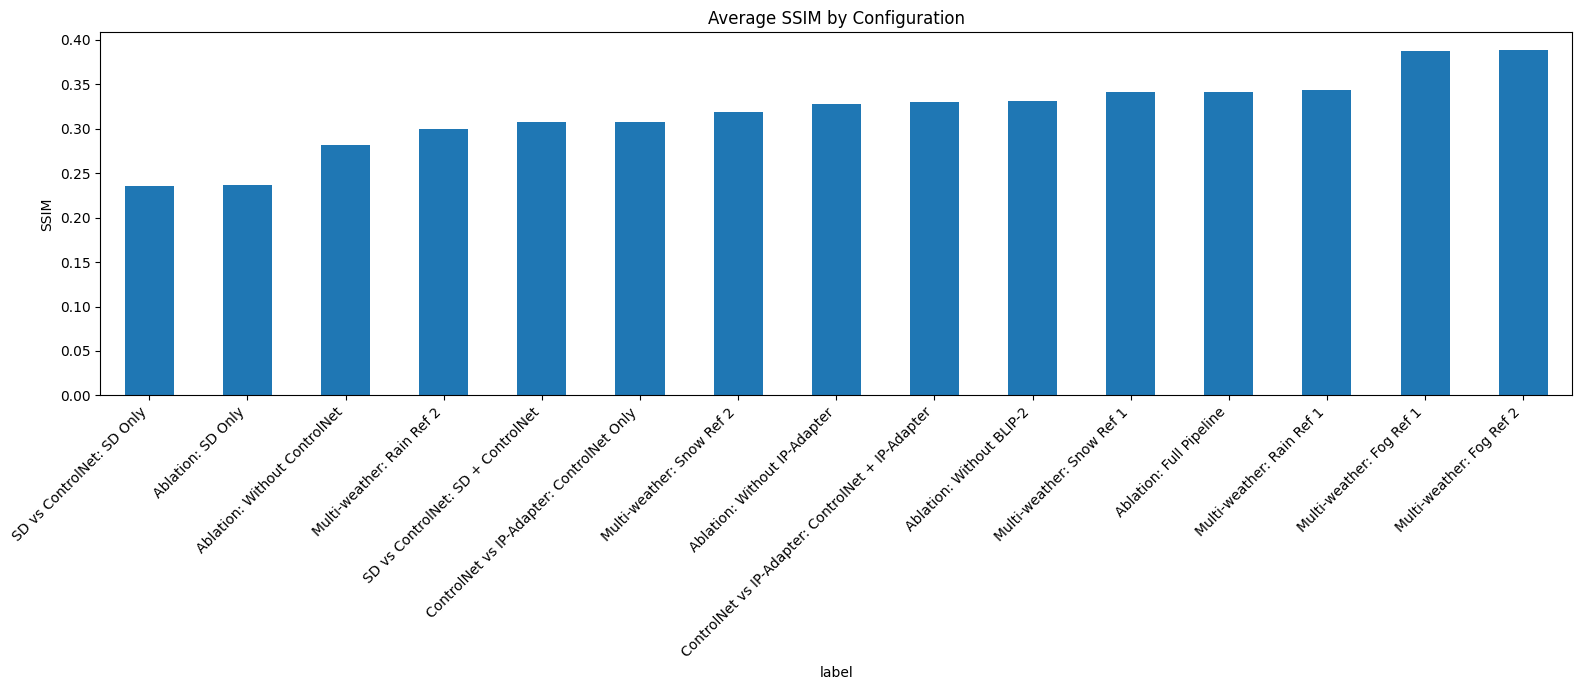

In [13]:
plt.figure(figsize=(16, 7))
summary.sort_values("ssim").plot(
    x="label",
    y="ssim",
    kind="bar",
    legend=False,
    figsize=(16, 7)
)
plt.title("Average SSIM by Configuration")
plt.ylabel("SSIM")
plt.xlabel("Pipeline configuration")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "ssim_summary.png"), dpi=300)
plt.show()

<Figure size 1600x700 with 0 Axes>

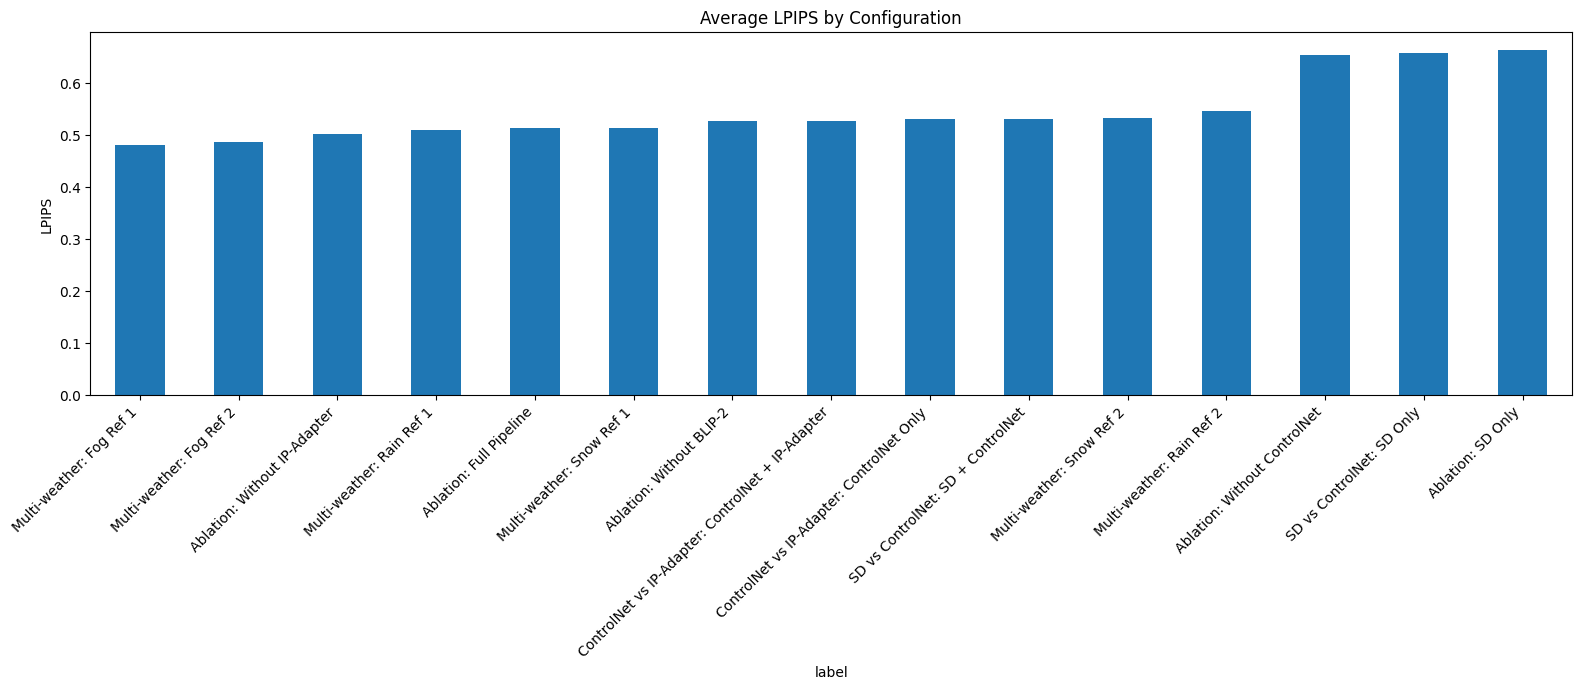

In [14]:
plt.figure(figsize=(16, 7))
summary.sort_values("lpips").plot(
    x="label",
    y="lpips",
    kind="bar",
    legend=False,
    figsize=(16, 7)
)
plt.title("Average LPIPS by Configuration")
plt.ylabel("LPIPS")
plt.xlabel("Pipeline configuration")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "lpips_summary.png"), dpi=300)
plt.show()

<Figure size 1600x700 with 0 Axes>

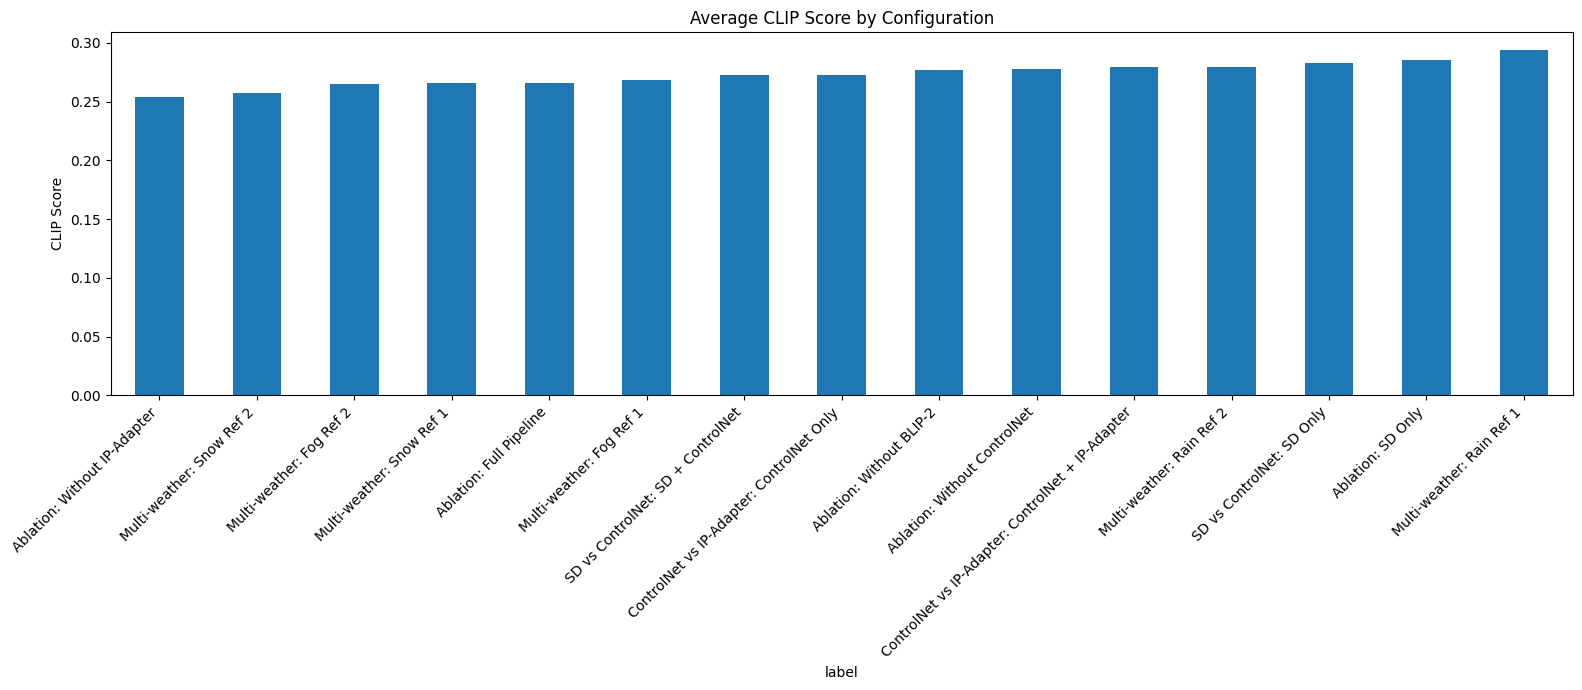

In [15]:
plt.figure(figsize=(16, 7))
summary.sort_values("clip_score").plot(
    x="label",
    y="clip_score",
    kind="bar",
    legend=False,
    figsize=(16, 7)
)
plt.title("Average CLIP Score by Configuration")
plt.ylabel("CLIP Score")
plt.xlabel("Pipeline configuration")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "clip_score_summary.png"), dpi=300)
plt.show()

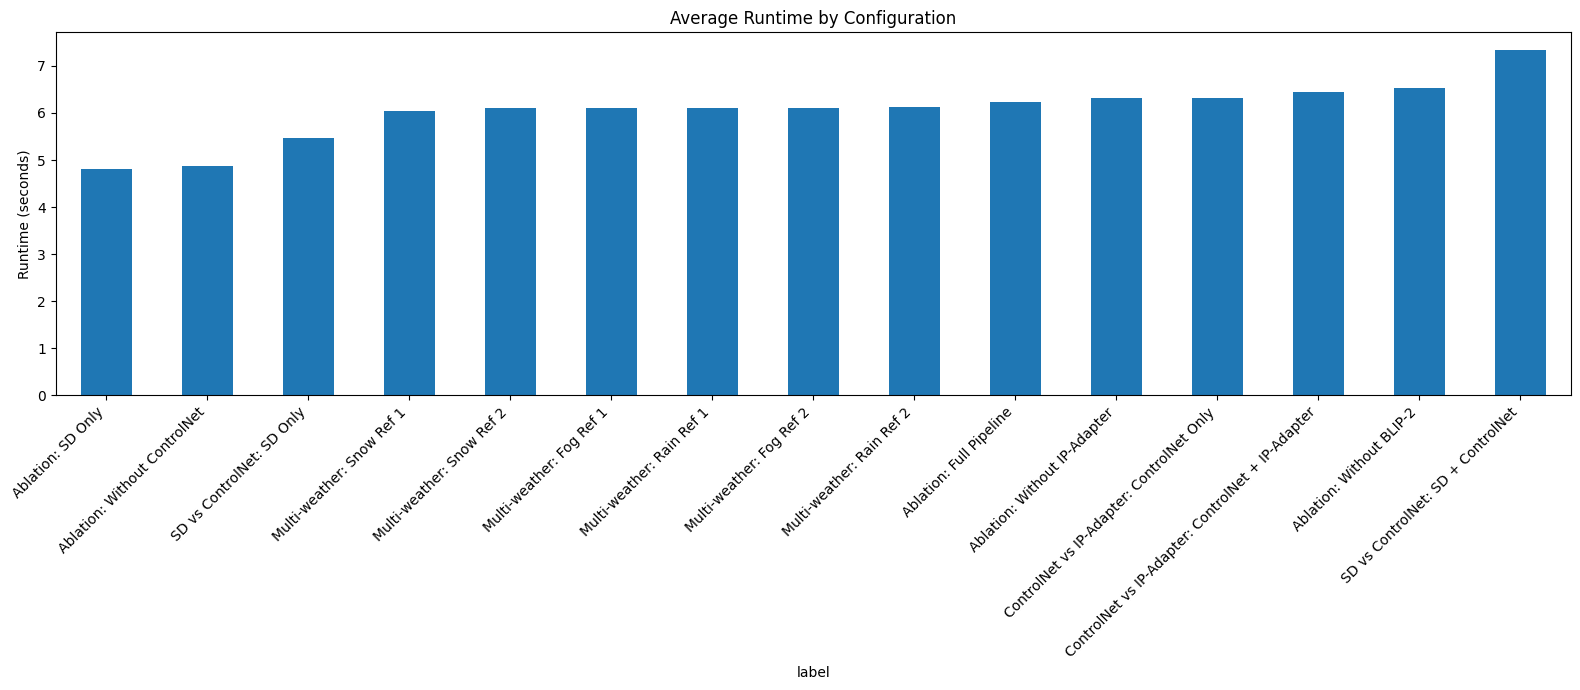

In [16]:
summary.sort_values("runtime_seconds").plot(
    x="label",
    y="runtime_seconds",
    kind="bar",
    legend=False,
    figsize=(16, 7)
)
plt.title("Average Runtime by Configuration")
plt.ylabel("Runtime (seconds)")
plt.xlabel("Pipeline configuration")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "runtime_summary.png"), dpi=300)
plt.show()

In [17]:
report_table = summary_rounded[[
    "label",
    "ssim",
    "lpips",
    "clip_score",
    "runtime_seconds"
]].copy()

report_table = report_table.rename(columns={
    "label": "Model / Configuration",
    "ssim": "SSIM",
    "lpips": "LPIPS",
    "clip_score": "CLIP Score",
    "runtime_seconds": "Runtime (s)"
})

report_table_path = os.path.join(metrics_dir, "metrics_report_table.csv")
report_table.to_csv(report_table_path, index=False)

report_table

,Model / Configuration,SSIM,LPIPS,CLIP Score,Runtime (s)
0,SD vs ControlNet: SD Only,0.235,0.658,0.283,5.473
1,SD vs ControlNet: SD + ControlNet,0.308,0.531,0.272,7.345
3,ControlNet vs IP-Adapter: ControlNet Only,0.308,0.531,0.273,6.317
2,ControlNet vs IP-Adapter: ControlNet + IP-Adapter,0.330,0.529,0.279,6.445
4,Ablation: SD Only,0.237,0.665,0.285,4.810
7,Ablation: Without ControlNet,0.281,0.655,0.277,4.871
8,Ablation: Without IP-Adapter,0.327,0.503,0.254,6.309
6,Ablation: Without BLIP-2,0.331,0.527,0.277,6.525
5,Ablation: Full Pipeline,0.341,0.514,0.266,6.227
13,Multi-weather: Snow Ref 1,0.341,0.514,0.266,6.036


In [18]:
print("Saved:")
print(csv_path)
print(summary_path)
print(report_table_path)
print(metrics_dir)

Saved:
/content/image-data-generation/results/metrics/metrics_summary.csv
/content/image-data-generation/results/metrics/metrics_average_summary.csv
/content/image-data-generation/results/metrics/metrics_report_table.csv
/content/image-data-generation/results/metrics


In [19]:
del lpips_model
del clip_model
del clip_processor

gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared.")

GPU memory cleared.
